In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length*1, 0., 0.)),
    ('H', (bond_length*2., 0., 0.)),
    ('H', (bond_length*3, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -2.09789961 Ha
FCI能量: -2.13888991 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [2]:
import itertools

# 排列组合
letters_alpha= [0,1,2,3]
letters_beta=  [4,5,6,7]
combinations_alpha = itertools.combinations(letters_alpha, 2)
combinations_beta =  itertools.combinations(letters_beta, 2)
clusters = list(combinations_alpha) + list(combinations_beta)
print(clusters)

[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [3]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=4,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(2, 2)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
# cluster = [(0,1),(2,3)]
#
# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=clusters)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [5]:
import flax.linen as nn

from flax.linen.dtypes import promote_dtype
from jax import numpy as jnp
from flax.linen.initializers import normal

from netket.utils.types import DType, Array, NNInitFunc


class Gaussian(nn.Module):
    r"""
    Multivariate Gaussian function with mean 0 and parametrised covariance matrix
    :math:`\Sigma_{ij}`.

    The wavefunction is given by the formula: :math:`\Psi(x) = \exp(\sum_{ij} x_i \Sigma_{ij} x_j)`.
    The (positive definite) :math:`\Sigma_{ij} = AA^T` matrix is stored as
    non-positive definite matrix A.
    """

    param_dtype: DType = jnp.float64
    """The dtype of the weights."""
    kernel_init: NNInitFunc = normal(stddev=1.0)
    """Initializer for the weights."""

    @nn.compact
    def __call__(self, x_in: Array):
        nv = x_in.shape[-1]

        kernel = self.param("kernel", self.kernel_init, (nv, nv), self.param_dtype)
        kernel = jnp.dot(kernel.T, kernel)

        kernel, x_in = promote_dtype(kernel, x_in, dtype=None)
        y = -0.5 * jnp.einsum("...i,ij,...j", x_in, kernel, x_in)

        return y

In [6]:
N = 8
Gauss = Gaussian()
vs = nk.vqs.MCState(sa, Gauss, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h4_molecule_ffnn"

In [7]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:13<00:00, 22.28it/s, Energy=1.248e-01 ± 2.453e-18 [σ²=3.081e-33, R̂=0.9843]]


(JsonLog('h4_molecule_ffnn', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.05884194374084473
   	Params: 0.05798506736755371,)

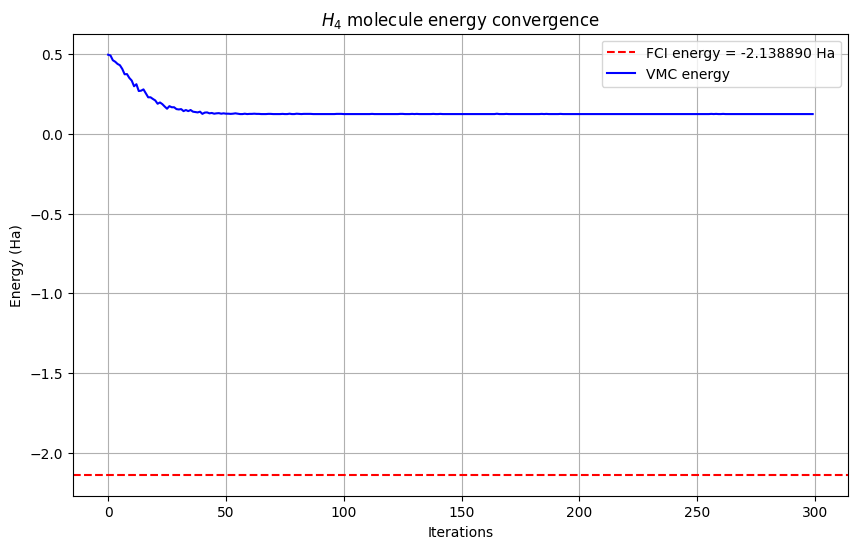


最终VMC能量: 0.12480138 Ha
与FCI能量误差: 2.26369130 Ha


In [8]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("$H_4$ molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")
